# Data Modeling with Power BI

### Overview

To reinforce my competency using business intellgence tools and understanding data from a design perspective, I wanted to include a case study showcasing the tasks that are integral to the BI profession by designing a proper data model using best practice techniques with relevant transactional sales data.

Data modeling is like creating a blueprint for how data is stored, managed, and retrievable within a business. It provides a structure that not only makes the data more accessible but also helps to align it with business goals and strategies.

**Characteristics of a good data model include**:
* Data that is easily understood and consumed
* Scalable when working with large datasets
* Provides predictable and optimal performance
* Flexible and adaptable, but not at the expense of other attributes

### Business Case

Although this is a fictitious case study, this scenario is very common problem that is encountered in the data analysis/BI profession. 

We're given a dataset comprised of transactional sales data comprised in a wide data format. The existing "one-table" data model is cumbersome to sift through and sometimes causing longer than usual performance/run-times when trying to generate reports.

The client wants us to re-design this data model in order to improve overall system performance and efficiency when storing and retrieving the data for reporting needs.

### Tools Used

In this analysis, we'll be using a combination of **Power Query** to do our prelimnary data inspection, cleansing, transformation and then use **Power BI** to construct our data model and establish relationshps between our tables.

### Schema Approach

From our initial data inspection, we can evaluate which dimensions we can break out into separate tables based on the characteristics of the attributes.

The sales data contains various customer, product, date, location, budget related fields for each sales transaction. We know that each record indicates a particular sales transaction that occurs over a period of time.

Conceptually, if we follow our **star schema** approach, we can designate our central **fact table** to 'Sales'. The FactSales table contains quantitative data, (number of units, unit price, unit cost). It also contains the foreign keys (Customer ID, Product ID, etc.) that will serve as a link to our dimension tables. Most importantly, the data in our fact table should be in stored in its highest level of **granularity**, or in other words, at the **most specific level of detail**. It is always easier to roll data up as opposed to breaking data down. If we store data at it's lowest level of detail, we lose dimensionality when modeling our data.

Our **dimension tables** are all the attributes or characteristics that describe the fact table. It is generally the descriptive, qualitative details that answers the question, sales "**by what?** by year? by month? by location? by what customer?". In this case, our dimension tables include characteristics such as the customer, product, geography, date, and possibly more as we continue with our analysis.

### Power Query Data Preparation and Transformation Steps

The main focus of this discussion pertains to the modeling aspect of our data, so rather than spending too much time going into detail about each task, I've included a quick summary our data cleaning/transformation steps after importing our .csv sales data file into Power Query:

1. Duplicate the query for each fact or dimension table we need to create
2. Rename each table to the respective fact or dimension table
3. Choose the specific columns that are relevant to each table
4. Extract customer information in the DimCustomer table from 'Email' column to create new customer attributes
5. Remove duplicate values for each table
6. Change necessary data types (Zip code from INT to Text, date values to date format, etc.)
7. Rename column headers
8. Create 'Date' dimension table using the Date Mformula [template](https://devinknightsql.com/2015/06/16/creating-a-date-dimension-with-power-query/)
9. Go back to original FactSales table and only select relevant columns
10. Save As - Close and Apply

### Defining Relationships in our Data Model

Once the data model is loaded, we can start to validate and piece together our data model in the model view of Power BI. We can see from our model view that our FactSales table serves as the center of our star schema. The PowerBI logic sets pre-defined table relationships in our data model based on it's evaluation of the attributes of our fact and dimension tables once you close the query editor and apply the changes. 

The pre-defined relationships from our **dimension tables are represented by a one (1)** meaning there is unique primary key that is associated to a foreign key(s) in our fact table where there are multiple instances of that event, represented by an asterick * . **A star schema data model should generally follow a one-to-many relationship cardinality**.

We can see from our model that there is not a relationship defined between our newly created 'DimDate' dimension table and our 'FactSales' fact table:

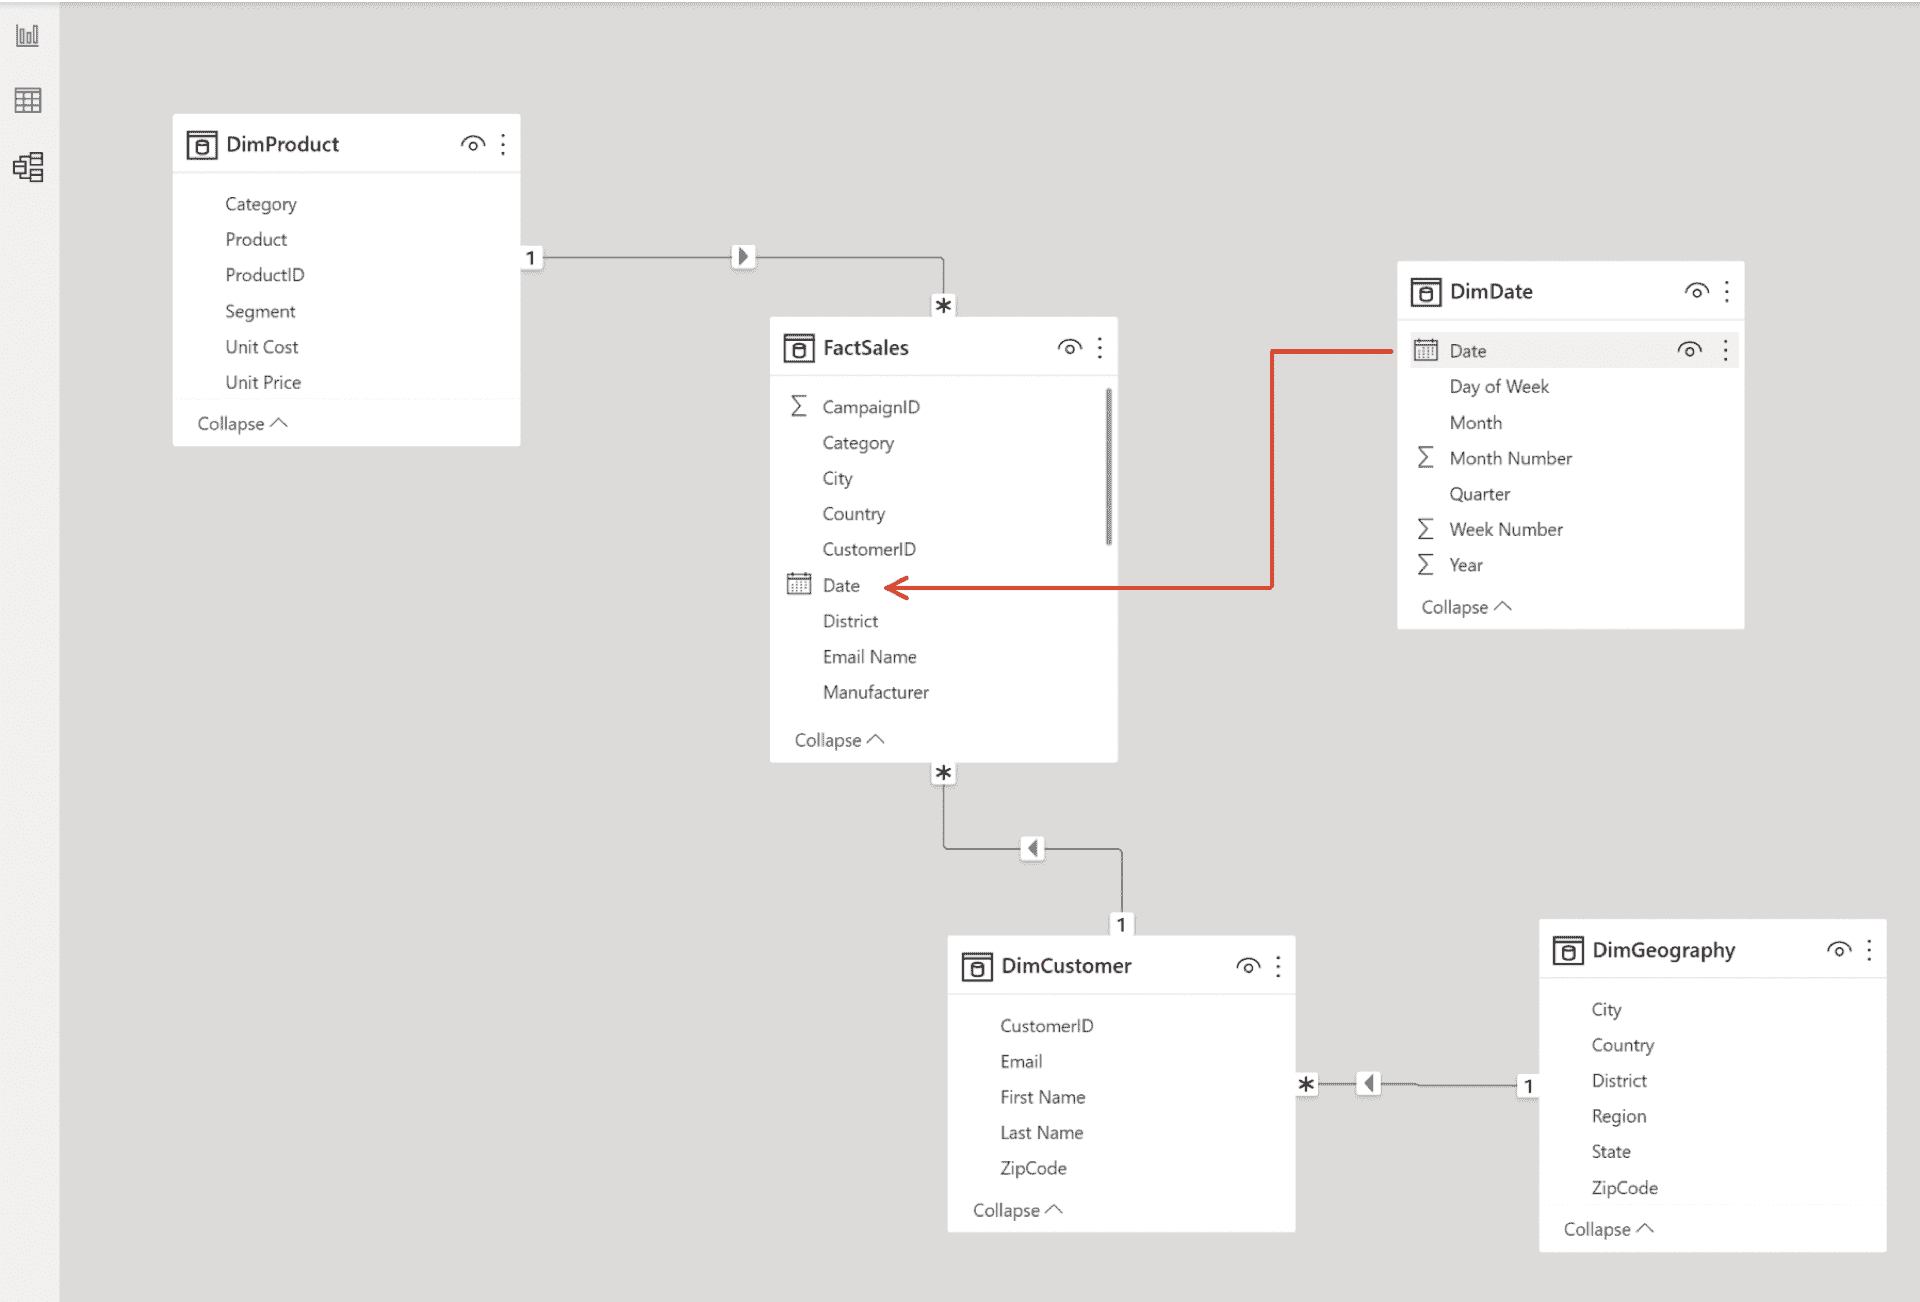

In order to establish an active relationship we would need to select/drag the attribute that we want to associate between the two tables, which is the 'Date' field. 

**Establishing table relationships is a necessary component to data modeling**. For example, if I were to create the following visual to display the total sales per year **prior** to establishing a relationship between the 'Date' field in my DimDate and FactSales table, this is the result I would get:

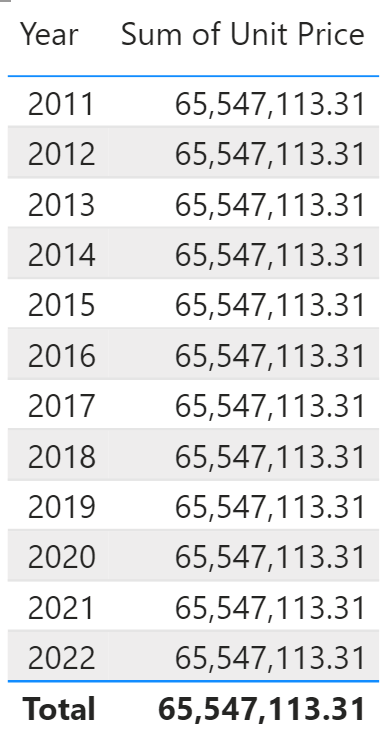

Now here are the results **after** establishing an active relationship:

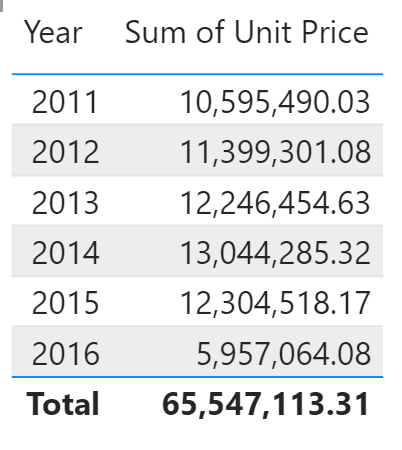


In the first image, we get a duplicated dollar amount which is not what we would expect to receive. If we don't establish a relationship between our tables then Power BI will be unable to **perform the appropriate data filtering, grouping, and aggregation across the related tables which will result in incorrect calculations** when creating our visualizations.

### Multiple Fact Tables

Even in a star schema, it is often common to have multiple fact tables. In the case of working with sales data, you may have additional fact tables to account for something in relation to a sales transaction, such as a return, inventory tracking, or in our case, budget/forecast.

In the dimensional modeling world, when we build our dimensions we want to build those dimensions not only so that they can form across multiple source systems, but also so that they can form across our different fact tables. It's important to establish this early on so that we can construct a model that is scalable, versatile and flexible without having to re-design the entire model after its been implemented.

We have a separate sales budget dataset that was provided to us, as the client also wants to account for this within the data model.

After loading this budget .csv file into our model and inspecting the data, we need to establish the relationship to our new 'FactBudget' table:

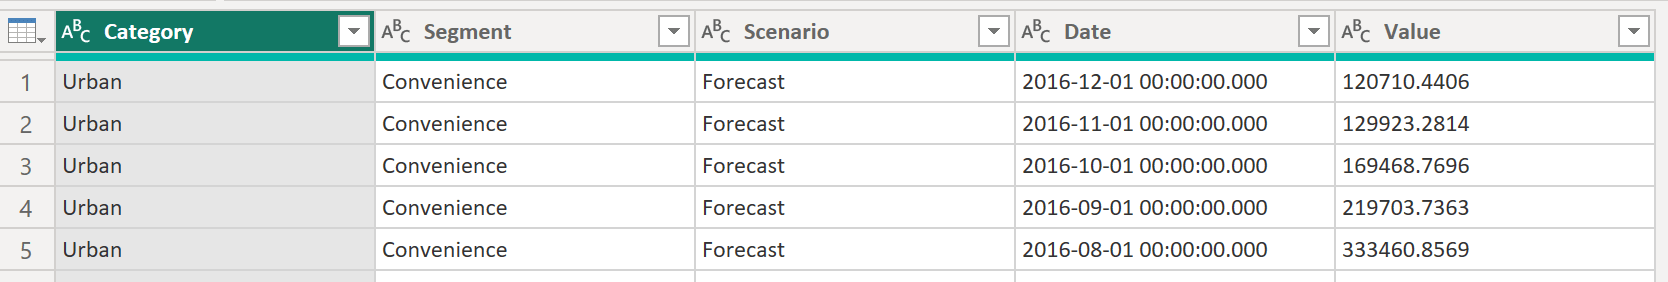

First, we can use the 'Date' field to create a relationship back to our 'DimDate' table.

Additionally, in both of our 'DimProduct' and 'FactBudget' table, we see that there is a 'Category' and 'Segment' column. These fields can be used to create a separate **bridge table** 'DimCatSeg' that would be used to join our 'DimProduct' and 'FactBudget' table.

Through the 'Category' and 'Segment' fields, we can create a unique **surrogate key** by creating a new index column from '1' to serve as a reference between these tables and then **join or merge** these tables back to one another through the 'Category' and 'Segment' fields:

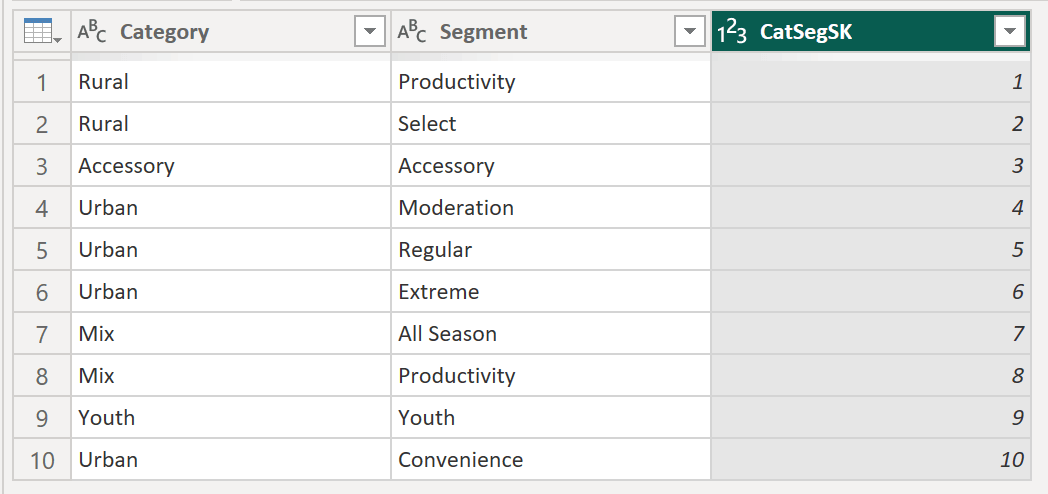

Join from DimProduct to DimCatSeg:

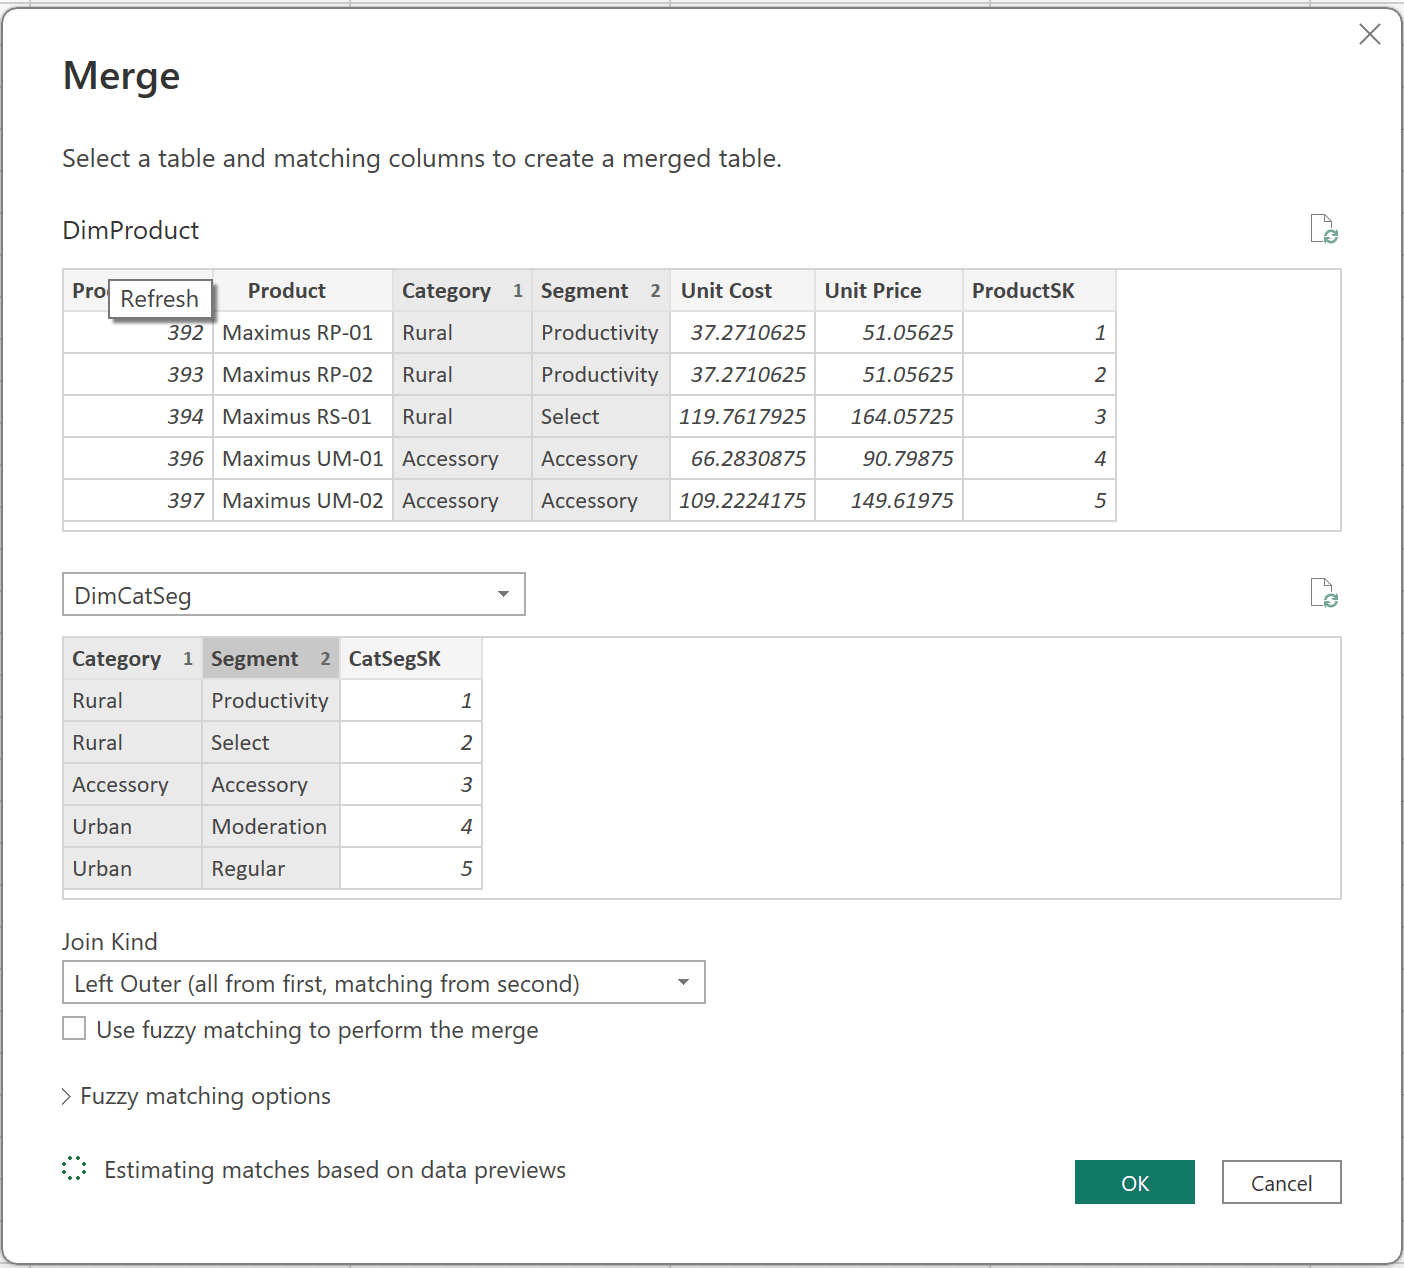

Join from FactBudget to DimCatSeg:

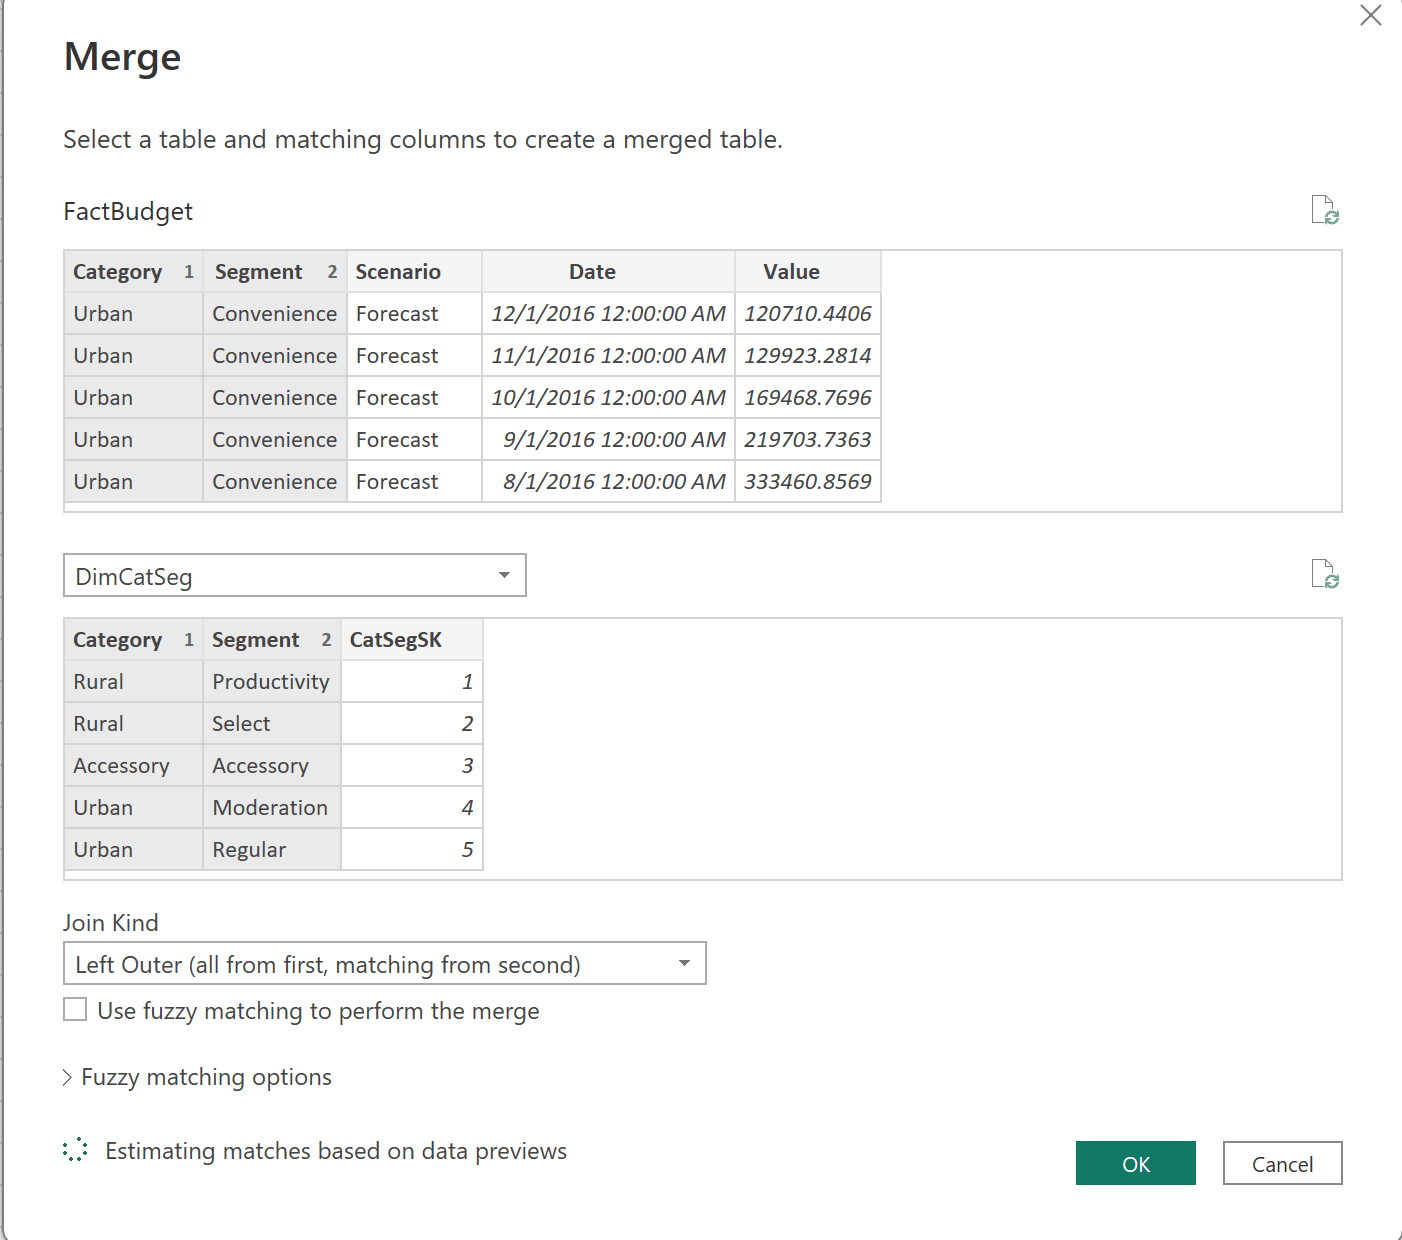

The resulting data model between our budget related data:

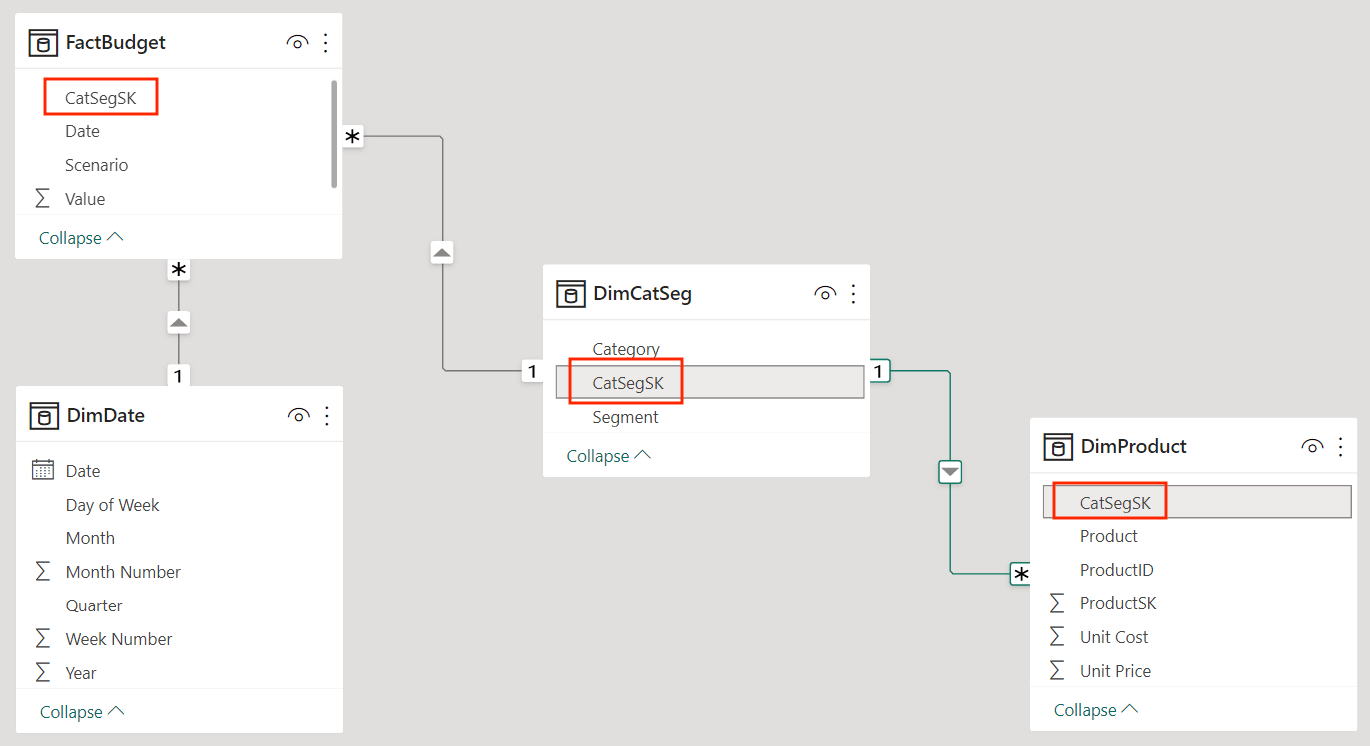

### The complete data model:

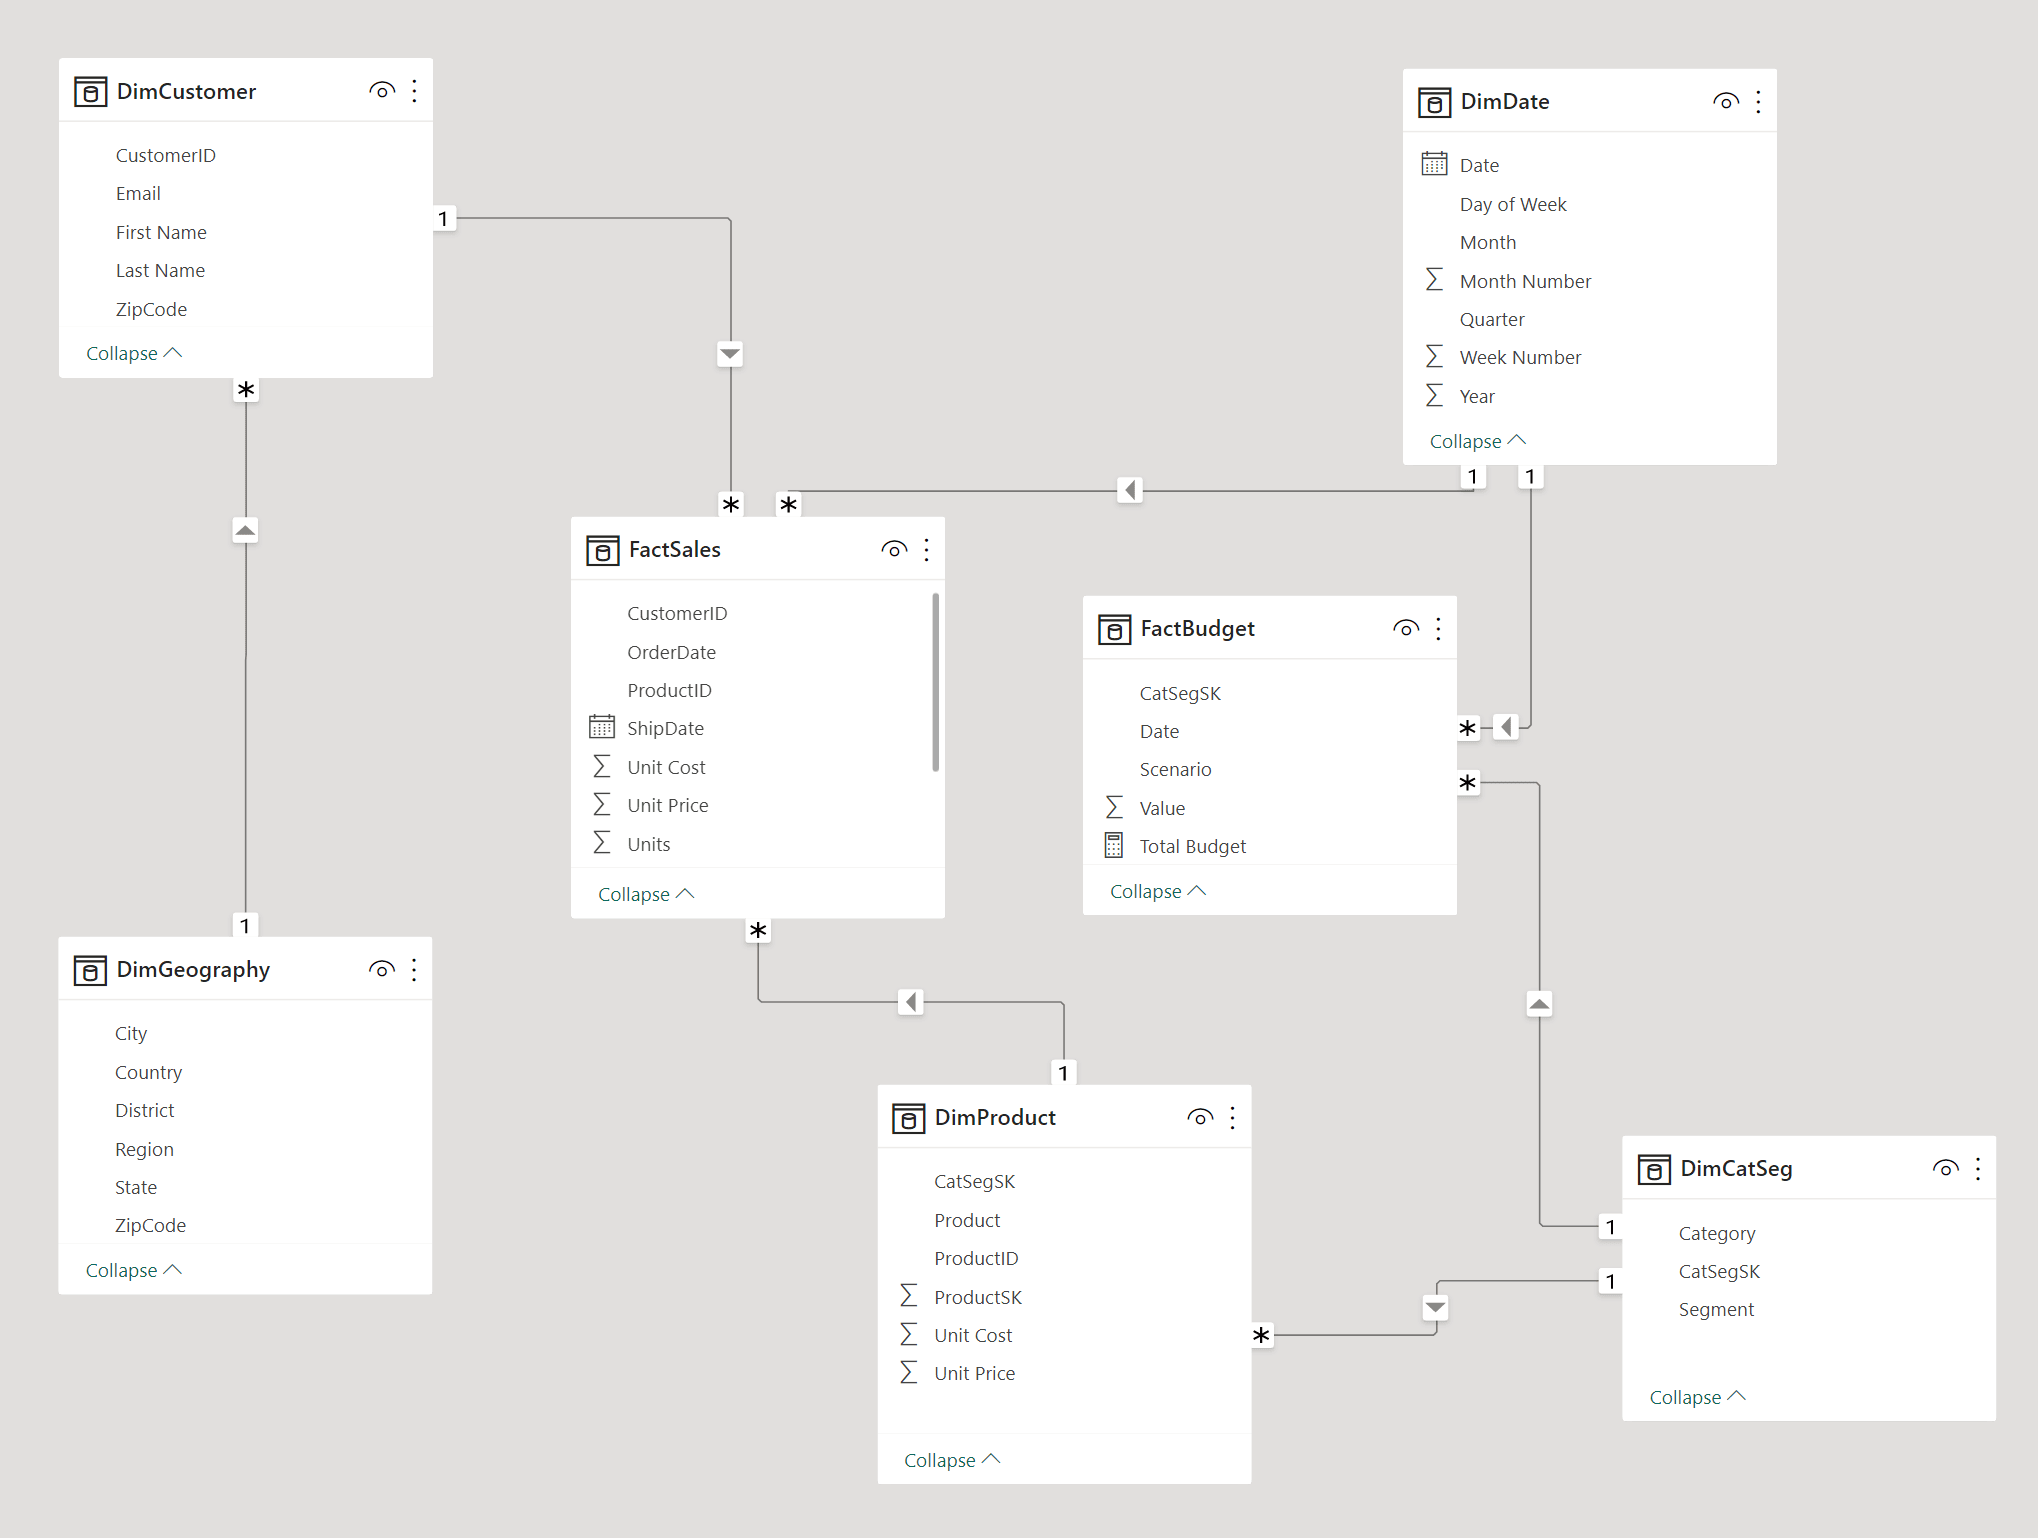

Through the process of modeling our data from the beginning of our analysis, we can see that our original star schema has progressed to a **snowflake schema** because of the addition of new dimension and fact tables.

There's various factors that will dictate the complexity of a data model schema for a business organization and how it evolves over time such as:

**Business Needs:** The primary driver of the data model schema choice is the organization's business requirements. What types of questions does the business need to answer? What kind of analytics will be performed on the data? Different types of schemas are optimized for different types of analysis.

**Volume:** The amount of the data also will also be a significant role. For smaller, simpler datasets, a simpler schema like a star schema may be suitable but as data grows and becomes more complex, a more intricate schema like a snowflake schema might be a better solution.

**Performance:** The performance requirements of the business intelligence or reporting needs also dictate the choice of schema. Some schemas might offer faster query performance but take up more storage space, while others might be more space-efficient but require more complex, slower queries.

**Adaptability and Scalability:** A data model might also evolve due to changes in the business environment or growth in the business itself. If new types of data are being collected, the data model might need to be updated to accommodate these changes.

**Data Governance and Compliance:** As organizations deal with sensitive information and have to comply with various data protection laws, the schema design should facilitate proper data governance and compliance with the laws.
